# Experimenting with the Router Pattern using Langgraph

In [1]:
from dotenv import load_dotenv
load_dotenv("../../.env")


from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

from qdrant_client.http.models import MatchValue, FieldCondition, Filter
import openai
from qdrant_client import QdrantClient
from langsmith import traceable, get_current_run_tree
import instructor
from pydantic import BaseModel, Field

from jinja2 import Template

/Users/dom/Documents/GitHub/e2e-engineering-course/E2E-AI-Engineering-Bootcamp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
from operator import add
from typing import List, Annotated

class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10
    question_relevant: bool = False


class QueryExpansionReponse(BaseModel):
    statements: List[str]

In [13]:
from jinja2 import Template

@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:
    instruction = """
    # Role: 
    - You are a query expansion module in a shopping assistent 

    # Task: 
    - You rewrite the customer query into distinct and unique statements. 
    - Generate 1 or more concise statements in natural language. 
    - Each statement describes a unique product or feature specified in the original query. 
    
    # Examples:
    
    <example>
    Query: "Can I get a smartwatch and some speakers for my house?"
    Statements: 
    - "Smartwatch"
    - "Loud Speakers"
    </example>

    <example>
    Query: "I need a warm jacket for hiking"
    Statements:
    - "insolated winter jacket"
    - "warm outdoor hiking cloths"
    </example>
    
    # Query:
    <query>
    {{ query }}
    </query>
    """

    template = Template(instruction)
    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=QueryExpansionReponse
    )

    return {
        "expanded_query": response.statements
    }

### Retriever Node

In [14]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State):

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(state["query"])

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01",
        query=query_embedding,
        limit=state["k"]
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])


    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

### Aggregator Node

In [15]:
class AggregatorResponse(BaseModel):
    answer: str

@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:
    preprocessed_context = "\n".join(state.retrieved_context)

    instruction = """
    # Role: 
    - You are a shopping assistent that can answer questions to the available products.

    # Task: 
    - You will be given a query and a list of context that should be used to answer the query
    - Do not invent or hallucinate items in stock
    - Don't use the word context instead refer to them as the items in stock
    - The answer should contain detailed information grounded in the given product specifications
    - If there are no relevant informations in the context assume that there is no product matching the users query
    
    # Context:
    <context>
    {{ context }}
    </context>

    # Query:
    <query>
    {{ query }}
    </query>
    """

    template = Template(instruction)
    prompt = template.render(
        context=preprocessed_context,
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=AggregatorResponse
    )

    return {
        "answer": response.answer
    }

### User Intent Router Node

In [26]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="A politely dismissive and humorous answer to the question if the users query is not relevant.")

In [27]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def intent_router_node(state: State) -> dict:

    instruction = """
    # Role: 
    - You are a relevancy router for a shopping assistent that answers questions about available products.

    # Task: 
    - Determine if the user query reltes to products, inventory or purchasing
    - Queries about product specs, features, availability, pricing, comparisons, ratings and recommendations are relevant
    - Queries about store policies, personal information, personal advise unrelated to products or unrelated topics to the shop products are not relevant
    
    # Examples:
    <example>
    Query: "Do you have Speakers under 150$"
    Relevant: Yes
    </example>

    <example>
    Query: "Can you help me do my homework?"
    Relevant: No - not related to products
    </example>

    <example>
    Query: "Which Tablet has the cheapest price?"
    Relevant: Yes
    </example>

    <example>
    Query: "How do I return an Item?"
    Relevant: No - about store policy, not product information
    </example>

    # Query:
    <query>
    {{ query }}
    </query>
    """

    template = Template(instruction)
    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        reasoning={"effort": "none"},
        response_model=IntentRouterResponse
    )

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [28]:
def intent_router_conditional_edges(state: State) -> dict:
    if state.question_relevant:
        return "query_expansion_node"
    else:
        return "end"

In [29]:
from langgraph.types import Send

def query_expand_conditional_edges(state: State) -> dict:
    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )

    return send_messages

In [30]:
workflow = StateGraph(State)

# nodes
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)
workflow.add_node("intent_router_node", intent_router_node)

# edges
workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "query_expansion_node": "query_expansion_node",
        "end": END
    }
)
workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges
)
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()


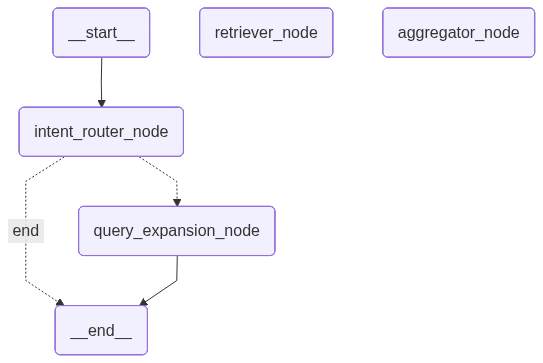

In [31]:
# We dont know how many retreiver_nodes will be expanded all of those will be connecting to the aggregator_node, but we cannot display it
display(Image(
    graph.get_graph().draw_mermaid_png()
))

In [22]:
initial_state = {
    "initial_query": "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
}

result = graph.invoke(initial_state)

In [23]:
result

{'expanded_query': ['Tablet for a kid',
  'Smartwatch for me',
  'Laptop for my wife'],
 'retrieved_context': ['- ID: B0BG6TMXDD, rating: 4.4, description: Fire HD 8 & HD 8 Plus Tablet Case for Kids (Only 12th Gen, 2022 Release) - DJ&RPPQ Lightweight Shockproof Cover with Handle Stand for Kindle Fire HD 8 Kids Tablet & Kids Pro Tablet - Blue Designed for Amazon All-New Kindle Fire HD 8 & Fire HD 8 Plus Tablet, Fire HD 8 Kids tablet & Fire HD 8 Kids Pro tablet (12th Generation 2022 Release), NOT fit for other models. Cutouts for clear access to all Amazon Kindle Fire HD 8 Plus / Fire HD 8 Tablet(12TH Generation, 2022Release) / Fire HD 8 Kids Pro 2022Tablet buttons, ports, speakers and rear-camera. Raised screen bezel edges for extra protection when fall. Kindle fire 8 case made with dense heavy duty EVA foam, Material can withstand considerable wear and tear and provide extreme shock protection.Super light weight and durable hazard free safe material perfect for kids and grownups alike.

In [32]:
# irrelevant question
initial_state = {
    "initial_query": "What is the hottest day recorded so far in germany?"
}

result = graph.invoke(initial_state)

In [33]:
result

{'retrieved_context': [],
 'initial_query': 'What is the hottest day recorded so far in germany?',
 'answer': 'That’s an interesting question—but I’m a shopping assistant, so I don’t have data on weather records like Germany’s hottest day. If you’d like, tell me what product you’re shopping for and I can help.',
 'question_relevant': False}